In [ ]:
import pandas as pd
import requests
import zipfile
import io

print("Libraries loaded ✅")
print(f"pandas version: {pd.__version__}")

Libraries loaded ✅
pandas version: 2.2.2


In [ ]:
url = "https://www.cftc.gov/files/dea/history/fut_fin_xls_2024.zip"

response = requests.get(url, timeout=30)

print(f"Status code: {response.status_code}")
print(f"File size downloaded: {len(response.content) / 1024:.1f} KB")

Status code: 200
File size downloaded: 1171.9 KB


In [ ]:
#Unzip file
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

print("Files inside the zip:", zip_file.namelist())

Files inside the zip: ['FinFutYY.xls']


In [ ]:
# install the xls reader and load it

!pip install xlrd -q

df = pd.read_excel(zip_file.open('FinFutYY.xls'), engine='xlrd')

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (3163, 84)
Rows: 3163, Columns: 84


In [ ]:
print(df.columns.tolist())

['Market_and_Exchange_Names', 'As_of_Date_In_Form_YYMMDD', 'Report_Date_as_MM_DD_YYYY', 'CFTC_Contract_Market_Code', 'CFTC_Market_Code', 'CFTC_Region_Code', 'CFTC_Commodity_Code', 'Open_Interest_All', 'Dealer_Positions_Long_All', 'Dealer_Positions_Short_All', 'Dealer_Positions_Spread_All', 'Asset_Mgr_Positions_Long_All', 'Asset_Mgr_Positions_Short_All', 'Asset_Mgr_Positions_Spread_All', 'Lev_Money_Positions_Long_All', 'Lev_Money_Positions_Short_All', 'Lev_Money_Positions_Spread_All', 'Other_Rept_Positions_Long_All', 'Other_Rept_Positions_Short_All', 'Other_Rept_Positions_Spread_All', 'Tot_Rept_Positions_Long_All', 'Tot_Rept_Positions_Short_All', 'NonRept_Positions_Long_All', 'NonRept_Positions_Short_All', 'Change_in_Open_Interest_All', 'Change_in_Dealer_Long_All', 'Change_in_Dealer_Short_All', 'Change_in_Dealer_Spread_All', 'Change_in_Asset_Mgr_Long_All', 'Change_in_Asset_Mgr_Short_All', 'Change_in_Asset_Mgr_Spread_All', 'Change_in_Lev_Money_Long_All', 'Change_in_Lev_Money_Short_All', 

In [ ]:
# Lets see all the Unique markets

print(df['Market_and_Exchange_Names'].unique())

['CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE'
 'SWISS FRANC - CHICAGO MERCANTILE EXCHANGE'
 'BRITISH POUND - CHICAGO MERCANTILE EXCHANGE'
 'JAPANESE YEN - CHICAGO MERCANTILE EXCHANGE'
 'EURO FX - CHICAGO MERCANTILE EXCHANGE'
 'AUSTRALIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE'
 'EURO FX/BRITISH POUND XRATE - CHICAGO MERCANTILE EXCHANGE'
 'EURO FX/JAPANESE YEN XRATE - CHICAGO MERCANTILE EXCHANGE'
 'USD/CHINESE RENMINBI-OFFSHORE  - CHICAGO MERCANTILE EXCHANGE'
 'MEXICAN PESO - CHICAGO MERCANTILE EXCHANGE'
 'BRAZILIAN REAL - CHICAGO MERCANTILE EXCHANGE'
 'NZ DOLLAR - CHICAGO MERCANTILE EXCHANGE'
 'SO AFRICAN RAND - CHICAGO MERCANTILE EXCHANGE'
 'DJIA Consolidated - CHICAGO BOARD OF TRADE'
 'DJIA x $5 - CHICAGO BOARD OF TRADE'
 'DOW JONES U.S. REAL ESTATE IDX - CHICAGO BOARD OF TRADE'
 'MICRO E-MINI DJIA (x$0.5) - CHICAGO BOARD OF TRADE'
 'S&P 500 Consolidated - CHICAGO MERCANTILE EXCHANGE'
 'E-MINI S&P CONSU STAPLES INDEX - CHICAGO MERCANTILE EXCHANGE'
 'E-MINI S&P ENERGY INDEX - CHICAGO

No Gold or Silver here. That's because this file is the Financial Futures report (fut_fin). Gold and Silver are physical commodities, so they live in a separate file.

In [ ]:
url_commodities = "https://www.cftc.gov/files/dea/history/fut_disagg_xls_2024.zip"

response_comm = requests.get(url_commodities, timeout=30)

print(f"Status code: {response_comm.status_code}")
print(f"File size: {len(response_comm.content) / 1024:.1f} KB")

Status code: 200
File size: 8845.6 KB


In [ ]:
zip_comm = zipfile.ZipFile(io.BytesIO(response_comm.content))
print("Files inside:", zip_comm.namelist())

df_comm = pd.read_excel(zip_comm.open(zip_comm.namelist()[0]), engine='xlrd')
print(f"\nShape: {df_comm.shape}")

Files inside: ['f_year.xls']

Shape: (13601, 188)


In [ ]:
gold_silver = df_comm[df_comm['Market_and_Exchange_Names'].str.contains('GOLD|SILVER', case=False, na=False)]

print(gold_silver['Market_and_Exchange_Names'].unique())

['SILVER - COMMODITY EXCHANGE INC.' 'GOLD - COMMODITY EXCHANGE INC.'
 'MICRO GOLD - COMMODITY EXCHANGE INC.']


let's filter down to just our 4 markets and keep only the columns we actually need

In [ ]:
# Filter each market
df_gold   = df_comm[df_comm['Market_and_Exchange_Names'] == 'GOLD - COMMODITY EXCHANGE INC.'].copy()
df_silver = df_comm[df_comm['Market_and_Exchange_Names'] == 'SILVER - COMMODITY EXCHANGE INC.'].copy()
df_jpy    = df[df['Market_and_Exchange_Names'] == 'JAPANESE YEN - CHICAGO MERCANTILE EXCHANGE'].copy()
df_chf    = df[df['Market_and_Exchange_Names'] == 'SWISS FRANC - CHICAGO MERCANTILE EXCHANGE'].copy()

print(f"Gold rows:   {len(df_gold)}")
print(f"Silver rows: {len(df_silver)}")
print(f"JPY rows:    {len(df_jpy)}")
print(f"CHF rows:    {len(df_chf)}")

Gold rows:   53
Silver rows: 53
JPY rows:    53
CHF rows:    53


In [ ]:
print(df_gold.columns.tolist())

['Market_and_Exchange_Names', 'As_of_Date_In_Form_YYMMDD', 'Report_Date_as_MM_DD_YYYY', 'CFTC_Contract_Market_Code', 'CFTC_Market_Code', 'CFTC_Region_Code', 'CFTC_Commodity_Code', 'Open_Interest_All', 'Prod_Merc_Positions_Long_ALL', 'Prod_Merc_Positions_Short_ALL', 'Swap_Positions_Long_All', 'Swap__Positions_Short_All', 'Swap__Positions_Spread_All', 'M_Money_Positions_Long_ALL', 'M_Money_Positions_Short_ALL', 'M_Money_Positions_Spread_ALL', 'Other_Rept_Positions_Long_ALL', 'Other_Rept_Positions_Short_ALL', 'Other_Rept_Positions_Spread_ALL', 'Tot_Rept_Positions_Long_All', 'Tot_Rept_Positions_Short_All', 'NonRept_Positions_Long_All', 'NonRept_Positions_Short_All', 'Open_Interest_Old', 'Prod_Merc_Positions_Long_Old', 'Prod_Merc_Positions_Short_Old', 'Swap_Positions_Long_Old', 'Swap_Positions_Short_Old', 'Swap_Positions_Spread_Old', 'M_Money_Positions_Long_Old', 'M_Money_Positions_Short_Old', 'M_Money_Positions_Spread_Old', 'Other_Rept_Positions_Long_Old', 'Other_Rept_Positions_Short_Old',

In [ ]:
# check if currencies are also in the commodity disaggregated file

currencies = df_comm[df_comm['Market_and_Exchange_Names'].str.contains(
    'JAPANESE YEN|SWISS FRANC', case=False, na=False)]

print(currencies['Market_and_Exchange_Names'].unique())
print(f"\nRows found: {len(currencies)}")

[]

Rows found: 0


In [ ]:
rename_map = {
    'Lev_Money_Positions_Long_All':   'M_Money_Positions_Long_ALL',
    'Lev_Money_Positions_Short_All':  'M_Money_Positions_Short_ALL',
    'Lev_Money_Positions_Spread_All': 'M_Money_Positions_Spread_ALL',
    'Change_in_Lev_Money_Long_All':   'Change_in_M_Money_Long_All',
    'Change_in_Lev_Money_Short_All':  'Change_in_M_Money_Short_All',
    'Dealer_Positions_Long_All':      'Prod_Merc_Positions_Long_ALL',
    'Dealer_Positions_Short_All':     'Prod_Merc_Positions_Short_ALL',
}

df = df.rename(columns=rename_map)

# Re-filter JPY and CHF after renaming
df_jpy = df[df['Market_and_Exchange_Names'] == 'JAPANESE YEN - CHICAGO MERCANTILE EXCHANGE'].copy()
df_chf = df[df['Market_and_Exchange_Names'] == 'SWISS FRANC - CHICAGO MERCANTILE EXCHANGE'].copy()

print("Renamed columns. Checking JPY has the new names:")
print(df_jpy[['M_Money_Positions_Long_ALL', 'M_Money_Positions_Short_ALL']].head(2))

Renamed columns. Checking JPY has the new names:
     M_Money_Positions_Long_ALL  M_Money_Positions_Short_ALL
159                       31671                        73989
160                       31241                        68682


In [ ]:
# Fix date column for all 4 markets
for df_mkt, name in [(df_gold, 'Gold'), (df_silver, 'Silver'),
                      (df_jpy, 'JPY'), (df_chf, 'CHF')]:
    df_mkt['Report_Date_as_MM_DD_YYYY'] = pd.to_datetime(
        df_mkt['Report_Date_as_MM_DD_YYYY'], errors='coerce'
    )

# Check gold dates to see if any weeks are missing
dates = df_gold['Report_Date_as_MM_DD_YYYY'].sort_values().reset_index(drop=True)
gaps = dates.diff().dropna()

print("Gap between consecutive COT reports (should all be 7 days):")
print(gaps.value_counts())

Gap between consecutive COT reports (should all be 7 days):
Report_Date_as_MM_DD_YYYY
7 days    52
Name: count, dtype: int64


In [ ]:
print("Date range in each file:")
print(f"Commodity file: {df_comm['Report_Date_as_MM_DD_YYYY'].min()} to {df_comm['Report_Date_as_MM_DD_YYYY'].max()}")
print(f"Financial file: {df['Report_Date_as_MM_DD_YYYY'].min()} to {df['Report_Date_as_MM_DD_YYYY'].max()}")

Date range in each file:
Commodity file: 2024-01-02 00:00:00 to 2024-12-31 00:00:00
Financial file: 2024-01-02 00:00:00 to 2024-12-31 00:00:00


In [ ]:
years = list(range(2018, 2026))  # complete years
all_comm = []
all_fin  = []

for year in years:
    print(f"Downloading {year}...", end=" ")

    # Commodities
    url_c = f"https://www.cftc.gov/files/dea/history/fut_disagg_xls_{year}.zip"
    r_c = requests.get(url_c, timeout=30)
    z_c = zipfile.ZipFile(io.BytesIO(r_c.content))
    df_c = pd.read_excel(z_c.open(z_c.namelist()[0]), engine='xlrd')
    all_comm.append(df_c)

    # Financials
    url_f = f"https://www.cftc.gov/files/dea/history/fut_fin_xls_{year}.zip"
    r_f = requests.get(url_f, timeout=30)
    z_f = zipfile.ZipFile(io.BytesIO(r_f.content))
    df_f = pd.read_excel(z_f.open(z_f.namelist()[0]), engine='xlrd')
    all_fin.append(df_f)

    print(f"✅  ({len(df_c)} commodity rows, {len(df_f)} financial rows)")

print("\nDone.")


Done.


In [ ]:
print(f"Status code: {r_c.status_code}")
print(f"Content type: {r_c.headers.get('content-type')}")
print(f"First 200 characters: {r_c.content[:200]}")

Status code: 200
Content type: application/zip
First 200 characters: b'PK\x03\x04\x14\x00\x00\x00\x08\x00!u"\\\xbe\xee\xe6\x8e\xaa\x15\x8b\x00\x00x\xa5\x02\n\x00\x00\x00f_year.xls\xe4\xbdyx\x14U\xf6\xc7}\xab\xb3o,\x82\xec`\xc9\x1e !{\x82\x80\xa4\xd3\xddI\x1a:\xdd\xa1\xbb\x93\x10\\B\x80\x00QHB\x12\x04\\\xc6\xe02n\xa8\xb8\xa3\xa2\x82\x1b\xee\xa2\x888.c\x18\x97\xd1\x91\x99\xc1]\xdc&\xee\xa3?Gqa\xdc\xc7\xf7T\xd59\xe7VWu\x92\xe6y\xde\xf7\xaf7>es\xbeu\xef\xb9k\xdd\xaaO\xdf[\xb7\x0f\xfcsp\xcf\x8e\x87F} ,\x7f\xb3E\x9c\xf8\xdf\xef)"\xd1\xa4\xdd\xe9\x10"\xa3Z1\x8cAB\x0c\x84\x7fk\xd6\xa3AE$h\x12\xd8\x83\xe18\n\x8e!p\x0c\x85\xe3'


In [ ]:
# Try different possible URL patterns for 2026
urls_to_try = [
    "https://www.cftc.gov/files/dea/history/fut_disagg_xls_2026_ytd.zip",
    "https://www.cftc.gov/files/dea/history/fut_disagg_xls_2026.zip",
    "https://www.cftc.gov/files/dea/history/f_year_2026.zip",
    "https://www.cftc.gov/files/dea/history/fut_disagg_2026_ytd.zip",
]

for url in urls_to_try:
    r = requests.get(url, timeout=10)
    print(f"{r.status_code}  {url}")

404  https://www.cftc.gov/files/dea/history/fut_disagg_xls_2026_ytd.zip
200  https://www.cftc.gov/files/dea/history/fut_disagg_xls_2026.zip
404  https://www.cftc.gov/files/dea/history/f_year_2026.zip
404  https://www.cftc.gov/files/dea/history/fut_disagg_2026_ytd.zip


In [ ]:
url_c_2026 = "https://www.cftc.gov/files/dea/history/fut_disagg_xls_2026.zip"
url_f_2026 = "https://www.cftc.gov/files/dea/history/fut_fin_xls_2026.zip"

# Commodities
r_c = requests.get(url_c_2026, timeout=30)
z_c = zipfile.ZipFile(io.BytesIO(r_c.content))
df_c_2026 = pd.read_excel(z_c.open(z_c.namelist()[0]), engine='xlrd')
all_comm.append(df_c_2026)

# Financials
r_f = requests.get(url_f_2026, timeout=30)
z_f = zipfile.ZipFile(io.BytesIO(r_f.content))
df_f_2026 = pd.read_excel(z_f.open(z_f.namelist()[0]), engine='xlrd')
all_fin.append(df_f_2026)

print(f"2026 YTD: {len(df_c_2026)} commodity rows, {len(df_f_2026)} financial rows")

2026 YTD: 5685 commodity rows, 1780 financial rows


combine all years

In [ ]:
master_comm = pd.concat(all_comm, ignore_index=True)
master_fin  = pd.concat(all_fin,  ignore_index=True)

print(f"Master commodity file: {master_comm.shape}")
print(f"Master financial file: {master_fin.shape}")

# Check date range
master_comm['Report_Date_as_MM_DD_YYYY'] = pd.to_datetime(
    master_comm['Report_Date_as_MM_DD_YYYY'], errors='coerce')
master_fin['Report_Date_as_MM_DD_YYYY']  = pd.to_datetime(
    master_fin['Report_Date_as_MM_DD_YYYY'],  errors='coerce')

print(f"\nCommodity date range: {master_comm['Report_Date_as_MM_DD_YYYY'].min()} "
      f"to {master_comm['Report_Date_as_MM_DD_YYYY'].max()}")
print(f"Financial date range:  {master_fin['Report_Date_as_MM_DD_YYYY'].min()} "
      f"to {master_fin['Report_Date_as_MM_DD_YYYY'].max()}")

Master commodity file: (100294, 188)
Master financial file: (24161, 84)

Commodity date range: 2018-01-02 00:00:00 to 2026-05-26 00:00:00
Financial date range:  2018-01-02 00:00:00 to 2026-05-26 00:00:00


In [ ]:
# filter down to just our 4 markets and apply the column renaming we did earlier

# Filter our 4 markets
df_gold   = master_comm[master_comm['Market_and_Exchange_Names'] == 'GOLD - COMMODITY EXCHANGE INC.'].copy()
df_silver = master_comm[master_comm['Market_and_Exchange_Names'] == 'SILVER - COMMODITY EXCHANGE INC.'].copy()
df_jpy    = master_fin[master_fin['Market_and_Exchange_Names'] == 'JAPANESE YEN - CHICAGO MERCANTILE EXCHANGE'].copy()
df_chf    = master_fin[master_fin['Market_and_Exchange_Names'] == 'SWISS FRANC - CHICAGO MERCANTILE EXCHANGE'].copy()

# Rename financial columns to match commodity naming
rename_map = {
    'Lev_Money_Positions_Long_All':   'M_Money_Positions_Long_ALL',
    'Lev_Money_Positions_Short_All':  'M_Money_Positions_Short_ALL',
    'Lev_Money_Positions_Spread_All': 'M_Money_Positions_Spread_ALL',
    'Change_in_Lev_Money_Long_All':   'Change_in_M_Money_Long_All',
    'Change_in_Lev_Money_Short_All':  'Change_in_M_Money_Short_All',
    'Dealer_Positions_Long_All':      'Prod_Merc_Positions_Long_ALL',
    'Dealer_Positions_Short_All':     'Prod_Merc_Positions_Short_ALL',
}
df_jpy = df_jpy.rename(columns=rename_map)
df_chf = df_chf.rename(columns=rename_map)

print(f"Gold:   {len(df_gold)} rows")
print(f"Silver: {len(df_silver)} rows")
print(f"JPY:    {len(df_jpy)} rows")
print(f"CHF:    {len(df_chf)} rows")

Gold:   439 rows
Silver: 439 rows
JPY:    439 rows
CHF:    439 rows


In [ ]:
# select only the columns we need and combine into one master dataframe

cols_to_keep = [
    'Report_Date_as_MM_DD_YYYY',
    'Market_and_Exchange_Names',
    'Open_Interest_All',
    'M_Money_Positions_Long_ALL',
    'M_Money_Positions_Short_ALL',
    'Prod_Merc_Positions_Long_ALL',
    'Prod_Merc_Positions_Short_ALL',
    'Change_in_Open_Interest_All',
    'Change_in_M_Money_Long_All',
    'Change_in_M_Money_Short_All',
    'NonRept_Positions_Long_All',
    'NonRept_Positions_Short_All',
]

df_gold['market']   = 'Gold'
df_silver['market'] = 'Silver'
df_jpy['market']    = 'JPY'
df_chf['market']    = 'CHF'

df_all = pd.concat([
    df_gold[cols_to_keep + ['market']],
    df_silver[cols_to_keep + ['market']],
    df_jpy[cols_to_keep + ['market']],
    df_chf[cols_to_keep + ['market']]
], ignore_index=True)

df_all = df_all.sort_values(['market', 'Report_Date_as_MM_DD_YYYY']).reset_index(drop=True)

print(f"Shape: {df_all.shape}")
print(f"\nDate range: {df_all['Report_Date_as_MM_DD_YYYY'].min()} to {df_all['Report_Date_as_MM_DD_YYYY'].max()}")
print(f"\nRows per market:\n{df_all['market'].value_counts()}")
print(f"\nMissing values:\n{df_all.isnull().sum()}")

Shape: (1756, 13)

Date range: 2018-01-02 00:00:00 to 2026-05-26 00:00:00

Rows per market:
market
CHF       439
Gold      439
JPY       439
Silver    439
Name: count, dtype: int64

Missing values:
Report_Date_as_MM_DD_YYYY        0
Market_and_Exchange_Names        0
Open_Interest_All                0
M_Money_Positions_Long_ALL       0
M_Money_Positions_Short_ALL      0
Prod_Merc_Positions_Long_ALL     0
Prod_Merc_Positions_Short_ALL    0
Change_in_Open_Interest_All      0
Change_in_M_Money_Long_All       0
Change_in_M_Money_Short_All      0
NonRept_Positions_Long_All       0
NonRept_Positions_Short_All      0
market                           0
dtype: int64


In [ ]:
# Check for gaps in each market separately
for mkt in ['Gold', 'Silver', 'JPY', 'CHF']:
    dates = df_all[df_all['market'] == mkt]['Report_Date_as_MM_DD_YYYY'].sort_values()
    gaps = dates.diff().dropna()
    non_7day = gaps[gaps != pd.Timedelta('7 days')]

    print(f"{mkt}: {len(non_7day)} gaps longer than 7 days")
    if len(non_7day) > 0:
        print(f"   {non_7day.values}")


Gold: 8 gaps longer than 7 days
   [518400000000000 691200000000000 518400000000000 691200000000000
 518400000000000 691200000000000 518400000000000 691200000000000]
Silver: 8 gaps longer than 7 days
   [518400000000000 691200000000000 518400000000000 691200000000000
 518400000000000 691200000000000 518400000000000 691200000000000]
JPY: 8 gaps longer than 7 days
   [518400000000000 691200000000000 518400000000000 691200000000000
 518400000000000 691200000000000 518400000000000 691200000000000]
CHF: 8 gaps longer than 7 days
   [518400000000000 691200000000000 518400000000000 691200000000000
 518400000000000 691200000000000 518400000000000 691200000000000]


Gaps exist. 8 per market, all identical across all 4 markets.

In [ ]:
for mkt in ['Gold']:  # just check Gold, same for all markets
    dates = df_all[df_all['market'] == mkt]['Report_Date_as_MM_DD_YYYY'].sort_values()
    gaps = dates.diff().dropna()
    non_7day = gaps[gaps != pd.Timedelta('7 days')]

    print(f"Gap date           →  Days skipped")
    print("-" * 40)
    for idx, gap in non_7day.items():
        gap_date = dates[idx]
        print(f"{gap_date.date()}  →  {gap.days} days")

Gap date           →  Days skipped
----------------------------------------
2018-12-24  →  6 days
2019-01-08  →  8 days
2020-12-21  →  6 days
2020-12-29  →  8 days
2023-07-03  →  6 days
2023-07-11  →  8 days
2025-11-10  →  6 days
2025-11-18  →  8 days


In [ ]:
# Rename the date column to something shorter, then do a final sanity check:

df_all = df_all.rename(columns={'Report_Date_as_MM_DD_YYYY': 'date'})

print(df_all.head(10))

        date                  Market_and_Exchange_Names  Open_Interest_All  \
0 2018-01-02  SWISS FRANC - CHICAGO MERCANTILE EXCHANGE              75662   
1 2018-01-09  SWISS FRANC - CHICAGO MERCANTILE EXCHANGE              77070   
2 2018-01-16  SWISS FRANC - CHICAGO MERCANTILE EXCHANGE              70214   
3 2018-01-23  SWISS FRANC - CHICAGO MERCANTILE EXCHANGE              71767   
4 2018-01-30  SWISS FRANC - CHICAGO MERCANTILE EXCHANGE              72587   
5 2018-02-06  SWISS FRANC - CHICAGO MERCANTILE EXCHANGE              73968   
6 2018-02-13  SWISS FRANC - CHICAGO MERCANTILE EXCHANGE              74651   
7 2018-02-20  SWISS FRANC - CHICAGO MERCANTILE EXCHANGE              69137   
8 2018-02-27  SWISS FRANC - CHICAGO MERCANTILE EXCHANGE              69018   
9 2018-03-06  SWISS FRANC - CHICAGO MERCANTILE EXCHANGE              62349   

   M_Money_Positions_Long_ALL  M_Money_Positions_Short_ALL  \
0                       31882                        39868   
1                

In [ ]:
# Build all features, one market at a time

def build_features(df_mkt):
    df = df_mkt.sort_values('date').copy()

    # Raw positions
    mm_long  = df['M_Money_Positions_Long_ALL']
    mm_short = df['M_Money_Positions_Short_ALL']
    oi       = df['Open_Interest_All']

    # Core features
    df['mm_net']            = mm_long - mm_short
    df['mm_net_pct']        = df['mm_net'] / oi * 100
    df['mm_long_short_ratio'] = mm_long / (mm_short + 1)
    df['mm_net_chg']        = df['mm_net'].diff(1)
    df['mm_net_ma4']        = df['mm_net'].rolling(4).mean()
    df['mm_net_ma13']       = df['mm_net'].rolling(13).mean()
    df['mm_dev_ma13']       = df['mm_net'] - df['mm_net_ma13']
    df['prod_net']          = df['Prod_Merc_Positions_Long_ALL'] - df['Prod_Merc_Positions_Short_ALL']
    df['retail_net']        = df['NonRept_Positions_Long_All'] - df['NonRept_Positions_Short_All']
    df['oi_chg_pct']        = oi.pct_change(1) * 100

    # COT Index — where is current mm_net in its 52-week range (0-100)
    df['cot_index'] = df['mm_net'].rolling(52).apply(
        lambda x: (x[-1] - x.min()) / (x.max() - x.min() + 1e-9) * 100,
        raw=True
    )

    return df

# Apply to each market
featured = {}
for mkt in ['Gold', 'Silver', 'JPY', 'CHF']:
    df_mkt = df_all[df_all['market'] == mkt].copy()
    featured[mkt] = build_features(df_mkt)
    print(f"{mkt}: {len(featured[mkt])} rows, {featured[mkt].shape[1]} columns")

Gold: 439 rows, 24 columns
Silver: 439 rows, 24 columns
JPY: 439 rows, 24 columns
CHF: 439 rows, 24 columns


In [ ]:
# Check NaN counts for just the feature columns
feature_cols = ['mm_net', 'mm_net_pct', 'mm_long_short_ratio', 'mm_net_chg',
                'mm_net_ma4', 'mm_net_ma13', 'mm_dev_ma13', 'prod_net',
                'retail_net', 'oi_chg_pct', 'cot_index']

print("NaN counts per feature (Gold):")
print(featured['Gold'][feature_cols].isnull().sum())


NaN counts per feature (Gold):
mm_net                  0
mm_net_pct              0
mm_long_short_ratio     0
mm_net_chg              1
mm_net_ma4              3
mm_net_ma13            12
mm_dev_ma13            12
prod_net                0
retail_net              0
oi_chg_pct              1
cot_index              51
dtype: int64


In [ ]:
!pip install yfinance -q

import yfinance as yf

tickers = {
    'Gold':   'GC=F',
    'Silver': 'SI=F',
    'JPY':    'JPY=X',
    'CHF':    'CHF=X'
}

prices = {}
for mkt, ticker in tickers.items():
    df_p = yf.download(ticker, start='2018-01-01', end='2026-05-27',
                       interval='1wk', progress=False, auto_adjust=True)
    df_p = df_p[['Close']].copy()
    df_p.columns = ['price']
    df_p.index = pd.to_datetime(df_p.index)
    prices[mkt] = df_p
    print(f"{mkt}: {len(df_p)} weekly bars  |  {df_p.index.min().date()} to {df_p.index.max().date()}")

Gold: 439 weekly bars  |  2018-01-01 to 2026-05-25
Silver: 439 weekly bars  |  2018-01-01 to 2026-05-25
JPY: 439 weekly bars  |  2018-01-01 to 2026-05-25
CHF: 439 weekly bars  |  2018-01-01 to 2026-05-25


In [ ]:
# compute next week's % price change

targets = {}
for mkt, df_p in prices.items():
    df_p = df_p.copy()
    df_p['next_week_return'] = df_p['price'].pct_change(1).shift(-1) * 100
    targets[mkt] = df_p
    print(f"{mkt}: sample target values")
    print(df_p[['price', 'next_week_return']].tail(5))
    print()


Gold: sample target values
                  price  next_week_return
Date                                     
2026-04-27  4629.899902          1.954686
2026-05-04  4720.399902         -3.486995
2026-05-11  4555.799805         -0.763857
2026-05-18  4521.000000         -1.625747
2026-05-25  4447.500000               NaN

Silver: sample target values
                price  next_week_return
Date                                   
2026-04-27  75.950996          5.851141
2026-05-04  80.394997         -4.022630
2026-05-11  77.161003         -1.643324
2026-05-18  75.892998         -1.705030
2026-05-25  74.598999               NaN

JPY: sample target values
                 price  next_week_return
Date                                    
2026-04-27  157.067993         -0.247027
2026-05-04  156.679993          1.277130
2026-05-11  158.681000          0.320771
2026-05-18  159.190002          0.033290
2026-05-25  159.242996               NaN

CHF: sample target values
               price  next_w

In [ ]:
# Merge COT features with price targets

merged = {}

for mkt in ['Gold', 'Silver', 'JPY', 'CHF']:
    # Get COT features
    cot = featured[mkt][['date'] + feature_cols].copy()

    # Get price target
    tgt = targets[mkt][['next_week_return']].copy()
    tgt.index = pd.to_datetime(tgt.index)

    # Merge on date — COT date to price date (nearest match within 3 days)
    cot['date'] = pd.to_datetime(cot['date'])
    cot = cot.set_index('date')

    df_merged = pd.merge_asof(
        cot.sort_index(),
        tgt.sort_index(),
        left_index=True,
        right_index=True,
        tolerance=pd.Timedelta('3 days'),
        direction='nearest'
    )

    # Drop NaNs from rolling windows and last row
    df_merged = df_merged.dropna()
    merged[mkt] = df_merged

    print(f"{mkt}: {len(df_merged)} rows after merge and dropna")

Gold: 387 rows after merge and dropna
Silver: 387 rows after merge and dropna
JPY: 387 rows after merge and dropna
CHF: 387 rows after merge and dropna


Gold    mean=0.35%  std=2.30%  up_weeks=59.9%  down_weeks=40.1%
Silver  mean=0.53%  std=4.79%  up_weeks=56.1%  down_weeks=43.9%
JPY     mean=0.10%  std=1.21%  up_weeks=56.8%  down_weeks=43.2%
CHF     mean=-0.05%  std=1.13%  up_weeks=50.1%  down_weeks=49.9%


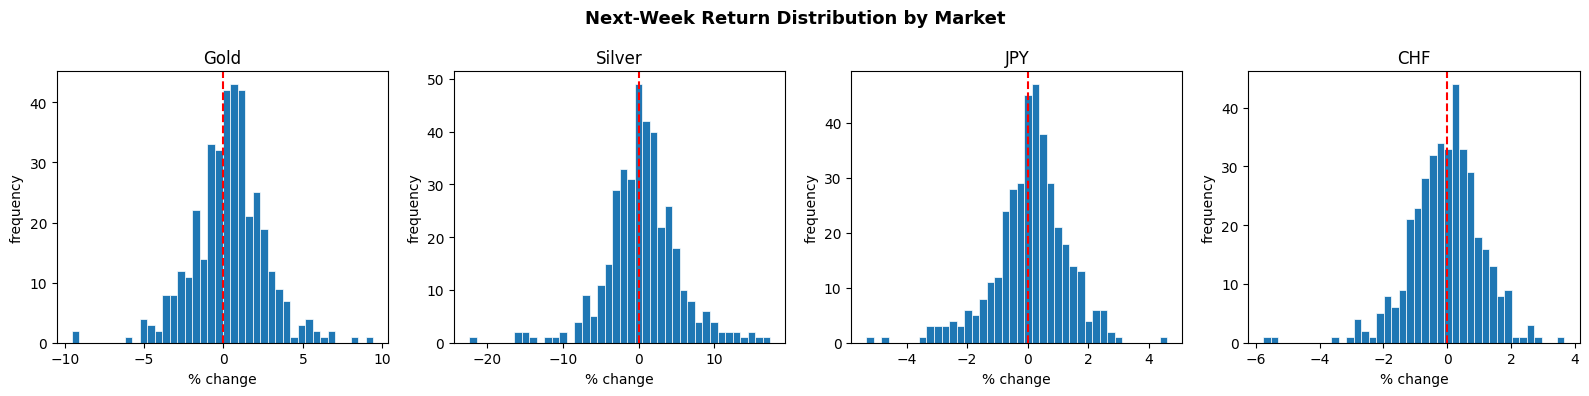

In [ ]:
# check the target distribution

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Next-Week Return Distribution by Market', fontsize=13, fontweight='bold')

for i, mkt in enumerate(['Gold', 'Silver', 'JPY', 'CHF']):
    t = merged[mkt]['next_week_return']
    axes[i].hist(t, bins=40, edgecolor='white', linewidth=0.5)
    axes[i].axvline(0, color='red', linewidth=1.5, linestyle='--')
    axes[i].set_title(mkt)
    axes[i].set_xlabel('% change')
    axes[i].set_ylabel('frequency')
    print(f"{mkt:6s}  mean={t.mean():.2f}%  std={t.std():.2f}%  "
          f"up_weeks={( t > 0).mean()*100:.1f}%  down_weeks={(t < 0).mean()*100:.1f}%")

plt.tight_layout()
plt.show()

In [ ]:
# correlation of each feature with next week's return

print(f"{'Feature':<25} {'Gold':>8} {'Silver':>8} {'JPY':>8} {'CHF':>8}")
print("-" * 58)

for feat in feature_cols:
    row = f"{feat:<25}"
    for mkt in ['Gold', 'Silver', 'JPY', 'CHF']:
        corr = merged[mkt][feat].corr(merged[mkt]['next_week_return'])
        row += f" {corr:>8.3f}"
    print(row)

Feature                       Gold   Silver      JPY      CHF
----------------------------------------------------------
mm_net                       0.019   -0.068    0.005    0.040
mm_net_pct                   0.027   -0.069   -0.010    0.007
mm_long_short_ratio          0.066   -0.052   -0.013   -0.003
mm_net_chg                  -0.113   -0.075   -0.008   -0.090
mm_net_ma4                   0.049   -0.051    0.008    0.053
mm_net_ma13                  0.044   -0.049    0.001    0.038
mm_dev_ma13                 -0.042   -0.033    0.007    0.011
prod_net                    -0.011    0.091   -0.015   -0.066
retail_net                  -0.050   -0.030   -0.022    0.067
oi_chg_pct                  -0.049   -0.082    0.002   -0.010
cot_index                   -0.008   -0.117   -0.007    0.029


In [ ]:
# import modelling libraries

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import numpy as np

print("Modelling libraries loaded ✅")

Modelling libraries loaded ✅


In [ ]:
# Define the evaluation function

def evaluate_models(mkt_name, df):

    X = df[feature_cols].values
    y = df['next_week_return'].values

    models = {
        'Ridge':          Ridge(alpha=1.0),
        'Random Forest':  RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
        'Gradient Boost': GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
        'XGBoost':        XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42, verbosity=0),
    }

    tscv = TimeSeriesSplit(n_splits=5)
    scaler = StandardScaler()

    results = {name: {'rmse': [], 'mae': [], 'r2': [], 'dir_acc': []} for name in models}

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        X_train_s = scaler.fit_transform(X_train)
        X_val_s   = scaler.transform(X_val)

        for name, model in models.items():
            # Ridge uses scaled data, tree models use raw
            if name == 'Ridge':
                model.fit(X_train_s, y_train)
                preds = model.predict(X_val_s)
            else:
                model.fit(X_train, y_train)
                preds = model.predict(X_val)

            rmse     = np.sqrt(mean_squared_error(y_val, preds))
            mae      = mean_absolute_error(y_val, preds)
            r2       = r2_score(y_val, preds)
            dir_acc  = np.mean(np.sign(preds) == np.sign(y_val)) * 100

            results[name]['rmse'].append(rmse)
            results[name]['mae'].append(mae)
            results[name]['r2'].append(r2)
            results[name]['dir_acc'].append(dir_acc)

    print(f"\n{'='*55}")
    print(f"  {mkt_name}")
    print(f"{'='*55}")
    print(f"{'Model':<18} {'RMSE':>7} {'MAE':>7} {'R²':>7} {'Dir%':>7}")
    print(f"{'-'*55}")

    for name in models:
        rmse    = np.mean(results[name]['rmse'])
        mae     = np.mean(results[name]['mae'])
        r2      = np.mean(results[name]['r2'])
        dir_acc = np.mean(results[name]['dir_acc'])
        print(f"{name:<18} {rmse:>7.3f} {mae:>7.3f} {r2:>7.3f} {dir_acc:>6.1f}%")

    return results

In [ ]:
all_results = {}

for mkt in ['Gold', 'Silver', 'JPY', 'CHF']:
    all_results[mkt] = evaluate_models(mkt, merged[mkt])


  Gold
Model                 RMSE     MAE      R²    Dir%
-------------------------------------------------------
Ridge                2.319   1.806  -0.147   54.7%
Random Forest        2.319   1.804  -0.137   56.6%
Gradient Boost       2.585   2.010  -0.445   52.8%
XGBoost              2.326   1.807  -0.146   55.3%

  Silver
Model                 RMSE     MAE      R²    Dir%
-------------------------------------------------------
Ridge                5.116   3.957  -0.227   55.9%
Random Forest        4.929   3.758  -0.144   53.1%
Gradient Boost       5.089   3.932  -0.226   52.8%
XGBoost              5.149   4.001  -0.250   50.0%

  JPY
Model                 RMSE     MAE      R²    Dir%
-------------------------------------------------------
Ridge                1.367   1.052  -0.570   50.3%
Random Forest        1.341   1.015  -0.412   50.6%
Gradient Boost       1.448   1.098  -0.747   50.0%
XGBoost              1.433   1.081  -0.719   50.6%

  CHF
Model                 RMSE     MAE 

In [ ]:
feature_importance_results = {}

for mkt in ['Gold', 'Silver', 'JPY', 'CHF']:
    X = merged[mkt][feature_cols].values
    y = merged[mkt]['next_week_return'].values

    rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
    rf.fit(X, y)

    imp_df = pd.DataFrame({
        'feature':    feature_cols,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    feature_importance_results[mkt] = imp_df

    print(f"\n{mkt} — Top 5 features:")
    print(imp_df.head(5).to_string(index=False))


Gold — Top 5 features:
    feature  importance
mm_net_ma13    0.193212
 retail_net    0.152221
   prod_net    0.117300
 mm_net_chg    0.108924
     mm_net    0.088446

Silver — Top 5 features:
    feature  importance
mm_net_ma13    0.209561
 mm_net_chg    0.146385
   prod_net    0.108249
  cot_index    0.102854
 oi_chg_pct    0.091822

JPY — Top 5 features:
    feature  importance
mm_net_ma13    0.193267
 mm_net_chg    0.125097
mm_dev_ma13    0.107163
  cot_index    0.096749
   prod_net    0.085545

CHF — Top 5 features:
   feature  importance
    mm_net    0.173767
oi_chg_pct    0.147386
mm_net_chg    0.131124
mm_net_ma4    0.113349
retail_net    0.080304


This tells us something important — the market doesn't respond to where positioning is, it responds to:

The trend of positioning over 13 weeks (mm_net_ma13)
The week-on-week change in positioning (mm_net_chg)



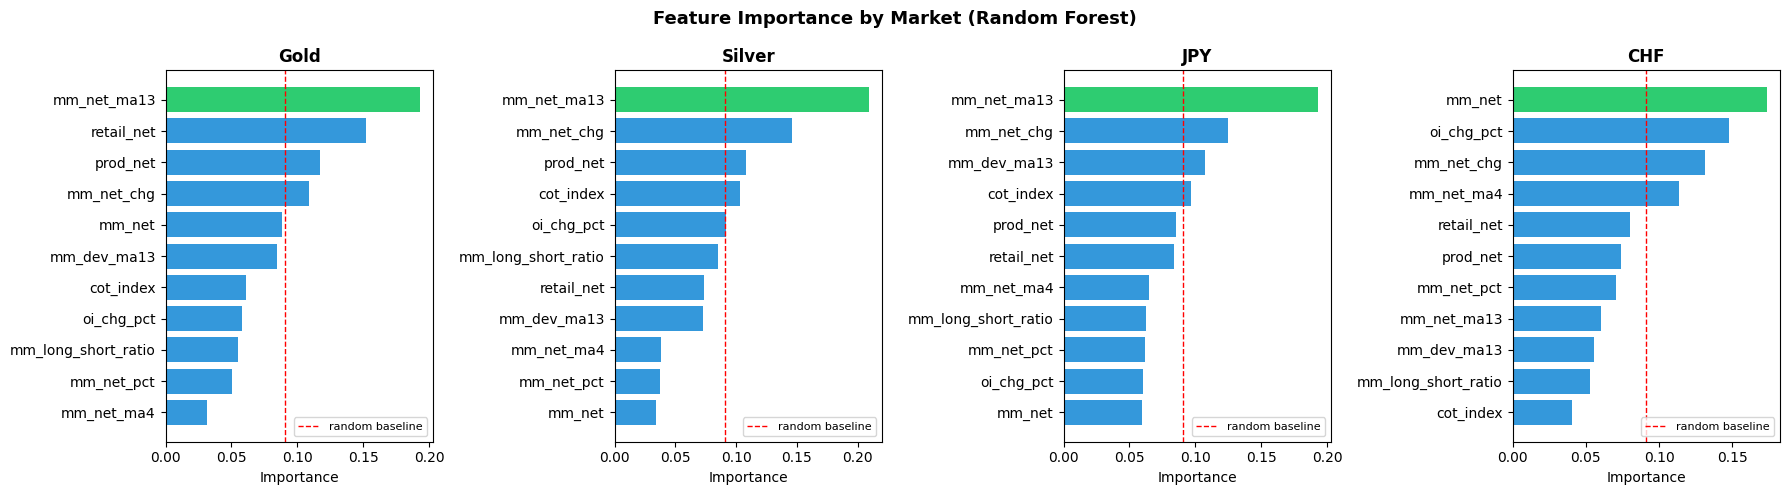

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Feature Importance by Market (Random Forest)', fontsize=13, fontweight='bold')

for i, mkt in enumerate(['Gold', 'Silver', 'JPY', 'CHF']):
    imp = feature_importance_results[mkt]
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(imp))]

    axes[i].barh(imp['feature'][::-1], imp['importance'][::-1], color=colors[::-1])
    axes[i].set_title(mkt, fontweight='bold')
    axes[i].set_xlabel('Importance')
    axes[i].axvline(1/len(feature_cols), color='red', linestyle='--',
                    linewidth=1, label='random baseline')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

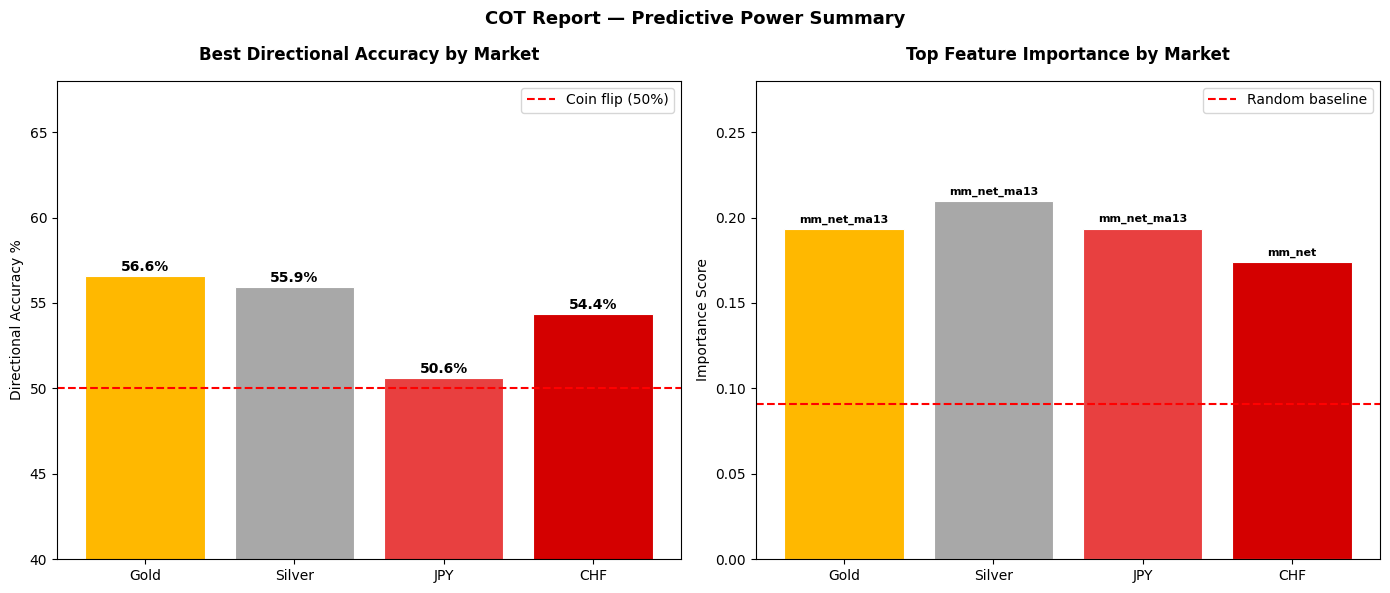

In [ ]:
# Final Summary Chart

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('COT Report — Predictive Power Summary', fontsize=13, fontweight='bold')

markets = ['Gold', 'Silver', 'JPY', 'CHF']
colors  = ['#FFB800', '#A8A8A8', '#E84040', '#D40000']

# Chart 1: Best directional accuracy per market
best_dir = {
    'Gold':   max(np.mean(all_results['Gold'][m]['dir_acc'])   for m in all_results['Gold']),
    'Silver': max(np.mean(all_results['Silver'][m]['dir_acc']) for m in all_results['Silver']),
    'JPY':    max(np.mean(all_results['JPY'][m]['dir_acc'])    for m in all_results['JPY']),
    'CHF':    max(np.mean(all_results['CHF'][m]['dir_acc'])    for m in all_results['CHF']),
}

bars = axes[0].bar(markets, best_dir.values(), color=colors, edgecolor='white', linewidth=0.8)
axes[0].axhline(50, color='red', linewidth=1.5, linestyle='--', label='Coin flip (50%)')
axes[0].set_title('Best Directional Accuracy by Market', fontweight='bold', pad=15)
axes[0].set_ylabel('Directional Accuracy %')
axes[0].set_ylim(40, 68)
axes[0].legend()
for bar, val in zip(bars, best_dir.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

# Chart 2: Top feature importance per market
top_features = {mkt: feature_importance_results[mkt].iloc[0]['feature'] for mkt in markets}
top_values   = {mkt: feature_importance_results[mkt].iloc[0]['importance'] for mkt in markets}

bars2 = axes[1].bar(markets, top_values.values(), color=colors, edgecolor='white', linewidth=0.8)
axes[1].axhline(1/len(feature_cols), color='red', linewidth=1.5, linestyle='--', label='Random baseline')
axes[1].set_title('Top Feature Importance by Market', fontweight='bold', pad=15)
axes[1].set_ylabel('Importance Score')
axes[1].set_ylim(0, 0.28)
axes[1].legend()
for bar, (mkt, feat) in zip(bars2, top_features.items()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 feat, ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

Best predictor across markets: mm_net_ma13
The 13-week moving average of hedge fund net positioning is the single most important COT feature for Gold, Silver and JPY. Not the raw level, not the weekly change — the medium-term trend.
Directional accuracy:

Gold: 56.6% — genuine signal, COT is useful

Silver: 55.9% — genuine signal, COT is useful

CHF: 54.4% — weak signal, use with caution

JPY: 50.6% — essentially no signal, COT alone is insufficient

Key lessons learned:

COT works best for physical commodities where institutional positioning dominates
Simpler models (Ridge, Random Forest) beat complex ones with limited data
Raw positioning (mm_net) is weaker than its trend and momentum derivatives.

COT is largely a contrarian indicator — extreme longs often precede price drops

In [ ]:
# The raw position columns for each player
player_cols = [
    'M_Money_Positions_Long_ALL',
    'M_Money_Positions_Short_ALL',
    'Prod_Merc_Positions_Long_ALL',
    'Prod_Merc_Positions_Short_ALL',
    'NonRept_Positions_Long_All',
    'NonRept_Positions_Short_All',
]

# Nicer labels for the chart
player_labels = [
    'Hedge Fund Long',
    'Hedge Fund Short',
    'Commercial Long',
    'Commercial Short',
    'Retail Long',
    'Retail Short',
]

# Build correlation matrix: players vs next_week_return, across all 4 markets
corr_matrix = pd.DataFrame(index=player_labels)

for mkt in ['Gold', 'Silver', 'JPY', 'CHF']:
    # Merge raw positions back with target
    df_mkt = featured[mkt][['date'] + player_cols].copy()
    df_mkt = df_mkt.set_index('date')
    tgt = merged[mkt][['next_week_return']]
    df_combined = df_mkt.join(tgt, how='inner')

    corrs = []
    for col in player_cols:
        corrs.append(df_combined[col].corr(df_combined['next_week_return']))

    corr_matrix[mkt] = corrs

print(corr_matrix.round(3))

                   Gold  Silver    JPY    CHF
Hedge Fund Long   0.018  -0.080 -0.014 -0.011
Hedge Fund Short -0.017  -0.006 -0.011 -0.068
Commercial Long   0.032  -0.005 -0.022 -0.069
Commercial Short  0.016  -0.079  0.006  0.029
Retail Long      -0.019  -0.032 -0.047  0.054
Retail Short      0.056   0.008 -0.025 -0.065


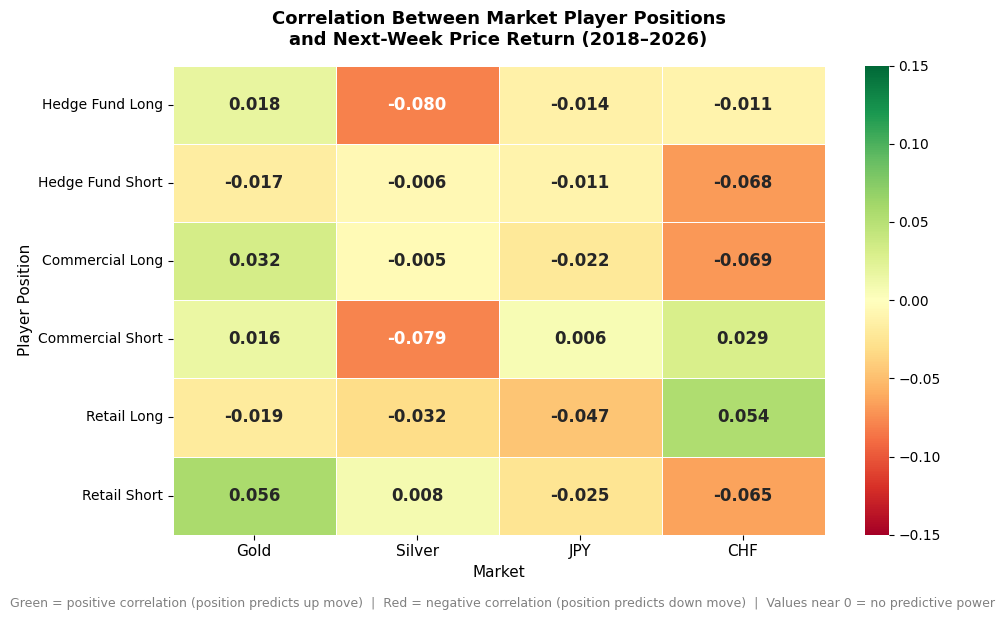

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Create heatmap
sns.heatmap(
    corr_matrix.astype(float),
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-0.15,
    vmax=0.15,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'},
    ax=ax
)

ax.set_title(
    'Correlation Between Market Player Positions\nand Next-Week Price Return (2018–2026)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Market', fontsize=11)
ax.set_ylabel('Player Position', fontsize=11)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10, rotation=0)

# Add a note
fig.text(0.5, -0.02,
         'Green = positive correlation (position predicts up move)  |  ' +
         'Red = negative correlation (position predicts down move)  |  ' +
         'Values near 0 = no predictive power',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('cot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

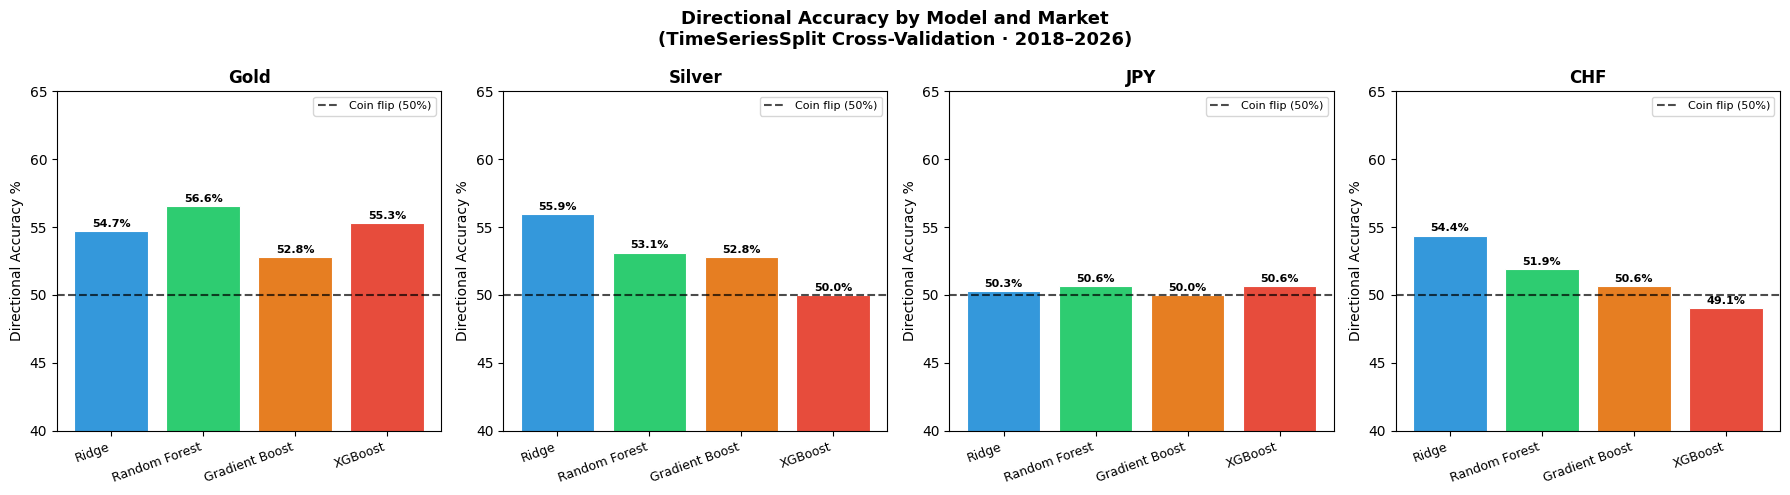

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Directional Accuracy by Model and Market\n(TimeSeriesSplit Cross-Validation · 2018–2026)',
             fontsize=13, fontweight='bold')

model_names = ['Ridge', 'Random Forest', 'Gradient Boost', 'XGBoost']
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

for i, mkt in enumerate(['Gold', 'Silver', 'JPY', 'CHF']):
    dir_accs = [np.mean(all_results[mkt][m]['dir_acc']) for m in model_names]
    bars = axes[i].bar(model_names, dir_accs, color=colors, edgecolor='white', linewidth=0.8)
    axes[i].axhline(50, color='black', linewidth=1.5, linestyle='--', alpha=0.7, label='Coin flip (50%)')
    axes[i].set_title(mkt, fontweight='bold', fontsize=12)
    axes[i].set_ylim(40, 65)
    axes[i].set_ylabel('Directional Accuracy %')
    axes[i].set_xticks(range(len(model_names)))
    axes[i].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, dir_accs):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()